## ***初始化相关***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import copy

from sympy.physics.quantum.gate import normalized
from tqdm import tqdm
import pandas as pd

import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torchvision
from torchvision import transforms

# 防止内核挂掉
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using Device: ',device)

Using Device:  cuda


In [3]:
BATCH_SIZE = 64
IMG_SIZE = [1000, 1000]
N_pixels = 1024
PhaseMask = [1200, 1200]
PIXEL_SIZE = 8e-6
wl = 532e-9
PADDINGx = (PhaseMask[0] - IMG_SIZE[0]) // 4  # 避免边缘信息丢失
PADDINGy = (PhaseMask[1] - IMG_SIZE[1]) // 4  # 避免边缘信息丢失

# 数据预处理并加载
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Resize((IMG_SIZE[0], IMG_SIZE[1]), antialias=True),
    transforms.RandomRotation(degrees=1),
    #transforms.Pad([PADDINGx, PADDINGx, PADDINGy, PADDINGy], fill=(0), padding_mode='constant'),
    #transforms.Normalize((0.1307,), (0.3081,))
    transforms.RandomAffine(
        degrees=0,  # 不旋转
        translate=(0.03, 0.03),
        scale=(0.97, 1.03),  # 不缩放
        shear=None   # 不c剪切
    ),
    transforms.ElasticTransform(alpha=100.0, sigma=5.0),
    #transforms.Pad([PADDINGx, PADDINGx, PADDINGy, PADDINGy], padding_mode="edge"),
    transforms.Pad([PADDINGx, PADDINGx, PADDINGy, PADDINGy]),
    transforms.ColorJitter(brightness=0.4, contrast=0.4),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.RandomAdjustSharpness(sharpness_factor=2.0, p=0.5),
])
folder = "data_pairs"
type = "20250929Step0.2N"
dataset = "0.1N-0.3N"

type=None
dataset="discrete5cate"
if type!=None:
    dataset_name = type + "/" + dataset
else:
    dataset_name = dataset
train_dataset = torchvision.datasets.ImageFolder(f"{dataset_name}/train", transform=transform)
val_dataset = torchvision.datasets.ImageFolder(f"{dataset_name}/val", transform=transform)
train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 定义一个绘图函数
def image_plot(image_phase, label):
    norm = np.absolute(image_phase.cpu().numpy())
    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.imshow(np.round(norm, 5), cmap='RdBu') # 显示图片每个像素点的振幅
    ax1.axis('off')
    ax1.set_title('Amplitude')
    ax2.imshow(np.angle(image_phase.cpu().numpy()), cmap='RdBu')
    ax2.axis('off')  # 不显示坐标轴
    ax2.set_title('Phase')
    fig.suptitle("label={}".format(label), x=0.5, y=0.8)
    plt.show()

for i, (images, labels) in enumerate(train_dataloader):
    images = images.to(device)
    images_padded = F.pad(torch.squeeze(images), pad=(PADDINGx, PADDINGx, PADDINGy, PADDINGy))
    images_E = torch.sqrt(images_padded)
    images_phase = torch.exp(1j*2.0*np.pi*images_E) # 转换为相位图像
    labels = labels.to(device)

    #每20个批次绘制第一张图片（含shuffle导致每次运行结果不一样）
    if (i + 1) % 40 == 0:
        classes = torch.unique(labels).cpu().numpy()
        classes_num = len(classes)
        print('batch_number [{}/{}]'.format(i + 1, len(train_dataloader)))
        print('classes of the first batch: {}, number of classes: {}'.format(classes, classes_num))#  第一个batch的总类
        image_plot(images_phase[0], labels[0])


In [4]:
#print(images.shape)
print(torch.squeeze(images).shape)
print(images_padded.shape)
print(images_E.shape)

torch.Size([16, 1100, 1100])
torch.Size([16, 1200, 1200])
torch.Size([16, 1200, 1200])


## ***Diffractive Layer***

In [5]:
class Diffractive_Layer(torch.nn.Module):
    # 模型初始化（构造实例），默认实参波长为532e-9，网格总数50，网格大小2e-6，z方向传播0.002。
    def __init__(self, wl = wl, PhaseMask = PhaseMask, pixel_size = PIXEL_SIZE, distance = 0.2):
        super(Diffractive_Layer, self).__init__() # 初始化父类

        # 以1/d为单位频率，得到一系列频率分量[0, 1, 2, ···, N_pixels/2-1,-N_pixels/2, ···, -1]/(N_pixels*d)。
        fx = torch.fft.fftshift(torch.fft.fftfreq(PhaseMask[0], d = pixel_size)).float()
        fy = torch.fft.fftshift(torch.fft.fftfreq(PhaseMask[1], d = pixel_size)).float()
        fxx, fyy = torch.meshgrid(fx, fy) # 拉网格，每个网格坐标点为空间频率各分量。

        argument = (2 * np.pi)**2 * ((1. / wl) ** 2 - fxx ** 2 - fyy ** 2)

        # 计算传播场或倏逝场的模式kz，传播场kz为实数，倏逝场kz为复数
        tmp = np.sqrt(np.abs(argument))
        kz = torch.tensor(np.where(argument >= 0, tmp, 1j*tmp)).to(device)
        self.phase = torch.exp(1j * kz * distance).to(device)
        self.phase = torch.fft.fftshift(self.phase)
        
    def forward(self, E):
        # 定义单个衍射层内的前向传播
        E = E.to(torch.cfloat)
        fft_c = torch.fft.fft2(E) # 对电场E进行二维傅里叶变换
        #c = torch.fft.fftshift(fft_c) # 将零频移至张量中心
        c = fft_c
        angular_spectrum = torch.fft.ifft2(c * self.phase) # 卷积后逆变换得到响应的角谱
        return angular_spectrum

c:\Users\16329\OneDrive\Desktop\tmp\task1\.venv\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4319.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
C:\Users\16329\AppData\Local\Temp\ipykernel_36632\2512726197.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  tmp = np.sqrt(np.abs(argument))


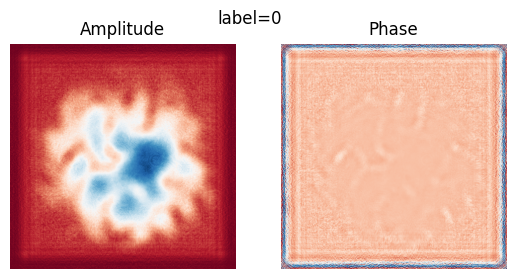

In [6]:
# 看一个样本经过衍射层后变成啥样
model = Diffractive_Layer()
E = torch.sqrt(images_padded[0])
out = model.forward(E)
image_plot(out, labels[0])

## ***Propagation Layer***

In [7]:
class Propagation_Layer(torch.nn.Module):
    # 与上面衍射层大致相同，区别在于传输层是最后一个衍射层到探测器层间的部分，中间可以自定义加额外的器件。
    def __init__(self, wl = wl, PhaseMask = PhaseMask, pixel_size = PIXEL_SIZE, distance = 0.2):
        super(Propagation_Layer, self).__init__() # 初始化父类

        # 以1/d为单位频率，得到一系列频率分量[0, 1, 2, ···, N_pixels/2-1,-N_pixels/2, ···, -1]/(N_pixels*d)。
        fx = torch.fft.fftshift(torch.fft.fftfreq(PhaseMask[0], d = pixel_size)).float()
        fy = torch.fft.fftshift(torch.fft.fftfreq(PhaseMask[1], d = pixel_size)).float()
        fxx, fyy = torch.meshgrid(fx, fy) # 拉网格，每个网格坐标点为空间频率各分量。

        argument = (2 * np.pi)**2 * ((1. / wl) ** 2 - fxx ** 2 - fyy ** 2)

        # 计算传播场或倏逝场的模式kz，传播场kz为实数，倏逝场kz为复数
        tmp = np.sqrt(np.abs(argument))
        kz = torch.tensor(np.where(argument >= 0, tmp, 1j*tmp))
        self.phase = torch.exp(1j * kz * distance).to(device)
        self.phase = torch.fft.fftshift(self.phase)
        
    def forward(self, E):
        # 定义单个衍射层内的前向传播
        E = E.to(torch.cfloat)
        fft_c = torch.fft.fft2(E) # 对电场E进行二维傅里叶变换
        # c = torch.fft.fftshift(fft_c) # 将零频移至张量中心
        c = fft_c
        angular_spectrum = torch.fft.ifft2(c * self.phase) # 卷积后逆变换得到响应的角谱
        return angular_spectrum

## ***Detectors Layer***

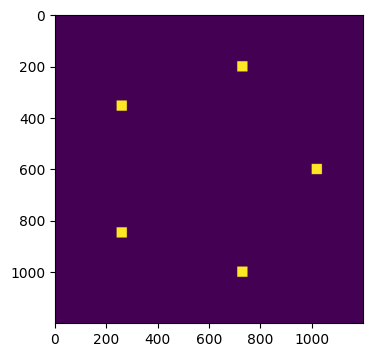

In [8]:
# 生成一行探测器。指定探测器个数N_det，在x方向上生成齐高等间距det_step的一组探测器
# left，right，up和down分别是该行矩形探测器的四个顶点坐标。
def generate_det_row(det_size, start_pos_x, start_pos_y, det_step, N_det):
    p = []
    for i in range(N_det):
        left = start_pos_x+i*(int(det_step)+det_size)
        right = left + det_size
        up = start_pos_y
        down = start_pos_y + det_size
        p.append((up, down, left, right))
    return p

# 生成三行探测器。利用generate_det_row函数生成三行等间距矩形探测器。
def set_det_pos(det_size = 60, start_pos_x = 36, start_pos_y = 36,
                N_det_sets = [2, 0, 2], det_steps_x = [5, 11, 5], det_steps_y = 5):
    p = []
    for i in range(len(N_det_sets)):
        p.append(generate_det_row(det_size, start_pos_x, start_pos_y+i*(det_steps_y+1)*det_size, det_steps_x[i]*det_size, N_det_sets[i]))
    return list(itertools.chain.from_iterable(p))

# def set_det_pos(det_size=20, start_pos_x = 46, start_pos_y = 46):
#     p = []
#     p.append(generate_det_row(det_size, start_pos_x, start_pos_y, 2*det_size, 3))
#     p.append(generate_det_row(det_size, start_pos_x, start_pos_y+3*det_size, 1*det_size, 4))
#     p.append(generate_det_row(det_size, start_pos_x, start_pos_y+6*det_size, 2*det_size, 3))
#     return list(itertools.chain.from_iterable(p))

# 获取最终衍射光强在各个探测器上的分布情况
def detector_region(Int):
    detectors_list = []
    total = 0
    full_Int = Int.sum(dim=(1,2)) # 统计总光强
    for det_x0, det_x1, det_y0, det_y1 in detector_pos: # 计算各个探测器区间内的光强占比
        detectors_list.append((Int[:, det_x0 : det_x1, det_y0 : det_y1].sum(dim=(1, 2))/full_Int).unsqueeze(-1))
    for ele in range(0, len(detectors_list)):
        total = total + detectors_list[ele]
    return torch.cat(detectors_list, dim = 1)/total

# 指定生成的探测器的位置。



"""
detector_pos = [
    (240, 320, 400, 480),
    (240, 320, 720, 800),
    (560, 640, 870, 950),
    (860, 940, 720, 800),
    (860, 940, 400, 480),
    (560, 640, 250, 330)
]
"""

# 定义探测器模型基本参数
det_size = 60
det_pad_x = (PhaseMask[0] - 13*det_size)//2
det_pad_y = (PhaseMask[1] - 13*det_size)//2
detector_pos = set_det_pos(det_size, det_pad_y, det_pad_x)
"""
#FourDown Circle
detector_pos = [
    (570, 630, 200, 260),
    (840, 900, 300, 360),
    (940, 1000, 570, 630),
    (840, 900, 840, 900)
]
"""
"""
# FourUp
detector_pos = [
    (200, 260, 200, 260),
    (200, 260, 570, 630),
    (200, 260, 940, 1000),
    (570, 630, 940, 1000)
]
"""
"""
# FourUp LR Circle
detector_pos = [
    (300, 360, 300, 360),
    (200, 260, 570, 630),
    (300, 360, 840, 900),
    (570, 630, 940, 1000)
]
"""
"""
# Eight Circle
detector_pos = [
    (300, 360, 300, 360),
    (200, 260, 570, 630),
    (300, 360, 840, 900),
    (570, 630, 940, 1000),
    (570, 630, 200, 260),
    (840, 900, 300, 360),
    (940, 1000, 570, 630),
    (840, 900, 840, 900)
]
"""
"""
#six circle
detector_pos = [
    (270, 330, 770, 830),
    (570, 630, 940, 1000),
    (870, 930, 770, 830),
    (870, 930, 370, 430),
    (570, 630, 200, 260),
    (270, 330, 370, 430)
]
"""

"""# Circle Ten Size40 Near
detector_pos = [
    (580, 620, 200, 240),
    (803, 843, 273, 313),
    (941, 981, 463, 503),
    (941, 981, 697, 737),
    (803, 843, 887, 927),
    (580, 620, 960, 1000),
    (357, 397, 887, 927),
    (219, 259, 697, 737),
    (219, 259, 463, 503),
    (357, 397, 273, 313)
]"""

"""
# Circle Ten Size40 Far
detector_pos = [
    (180, 220, 710, 750),
    (333, 373, 920, 960),
    (580, 620, 1000, 1040),
    (827, 867, 920, 960),
    (980, 1020, 710, 750),
    (980, 1020, 450, 490),
    (827, 867, 240, 280),
    (580, 620, 160, 200),
    (333, 373, 240, 280),
    (180, 220, 450, 490)
]"""

"""
# Circle Eight size 40
detector_pos = [
    (580, 620, 160, 200),
    (877, 917, 283, 323),
    (1000, 1040, 580, 620),
    (877, 917, 877, 917),
    (580, 620, 1000, 1040),
    (283, 323, 877, 917),
    (160, 200, 580, 620),
    (283, 323, 283, 323)
]
"""
"""
# Circle Eight size 60
detector_pos = [
    (300, 360, 300, 360),
    (200, 260, 570, 630),
    (300, 360, 840, 900),
    (570, 630, 940, 1000),
    (570, 630, 200, 260),
    (840, 900, 300, 360),
    (940, 1000, 570, 630),
    (840, 900, 840, 900)
]
"""

# Circle Five Size40 Far
detector_pos = [
    (180, 220, 710, 750),
    
    (580, 620, 1000, 1040),
    
    (980, 1020, 710, 750),
    
    (827, 867, 240, 280),
    
    (333, 373, 240, 280)
]

"""detector_pos = [
    (580, 620, 960, 1000),
    (580, 620, 200, 240)
]"""
# 定义探测器层的图片张量
labels_image_tensors=torch.zeros((10, PhaseMask[0], PhaseMask[1]), device = device, dtype = torch.float32)
for ind, pos in enumerate(detector_pos):
    pos_l, pos_r, pos_u, pos_d = pos
    labels_image_tensors[ind, pos_l:pos_r, pos_u:pos_d] = 1 # 设置探测器区域
    labels_image_tensors[ind] = labels_image_tensors[ind]/labels_image_tensors[ind].sum() # 归一化探测器层
det_ideal = labels_image_tensors.cpu().numpy().sum(axis = 0)

plt.rcParams["figure.figsize"] = (4, 4)
plt.imshow(det_ideal,'viridis') # 查看探测器层

## ***D2NN***

In [9]:
class DNN(torch.nn.Module):
    """""""""""""""""""""
    phase only modulation
    """""""""""""""""""""
    def __init__(self, num_layers = 1, wl = wl, PhaseMask = PhaseMask, pixel_size = PIXEL_SIZE,
                 distance_between_layers = 0.2, distance_to_detectors = 0.2):

        super(DNN, self).__init__()
        """
        # 初始化每层相位板的相位参数（0到1区间均匀分布）,并将其注册为可学习的Parameter。
        self.phase = [torch.nn.Parameter(torch.from_numpy(np.random.random(size=(PhaseMask[0], PhaseMask[1])).astype('float32'))) for _ in range(num_layers)]
        # 向网络中添加每层相位板的参数
        for i in range(num_layers):
            self.register_parameter("phase" + "_" + str(i), self.phase[i])
        """
        self.phase_mask = torch.nn.ParameterList([
            torch.nn.Parameter(torch.rand(PhaseMask, dtype=torch.float32)) for _ in range(num_layers)
        ])
        # 定义中间的衍射层
        self.diffractive_layers = torch.nn.ModuleList([Diffractive_Layer(wl, PhaseMask, pixel_size, distance_between_layers) for _ in range(num_layers)])
        # 定义最后的探测层
        self.last_diffractive_layer = Propagation_Layer(wl, PhaseMask, pixel_size, distance_to_detectors)
        self.sofmax = torch.nn.Softmax(dim=-1)

    # 计算多层衍射前向传播
    def forward(self, E):
        E = E.to(torch.cfloat)
        for index, layer in enumerate(self.diffractive_layers):
            temp = layer(E)
            # phase_values = 2 * np.pi * torch.sigmoid(self.phase_mask[index])
            phase_values = 2 * np.pi * self.phase_mask[index]
            # 这里相当于加了一层sigmoid非线性激活，将相位控制在0到2pi
            #             constr_phase = 2*np.pi*torch.sigmoid(self.phase[index])
            modulation = torch.exp(1j*phase_values) #torch.cos(constr_phase)+1j*torch.sin(constr_phase)
            E = temp * modulation
        E = self.last_diffractive_layer(E)
        Int = torch.abs(E)**2
        #output = self.sofmax(detector_region(x_abs))
        output = detector_region(Int)
        return output, Int

In [10]:
model = DNN().to(device)
print(model)

DNN(
  (phase_mask): ParameterList(  (0): Parameter containing: [torch.float32 of size 1200x1200 (cuda:0)])
  (diffractive_layers): ModuleList(
    (0): Diffractive_Layer()
  )
  (last_diffractive_layer): Propagation_Layer()
  (sofmax): Softmax(dim=-1)
)


C:\Users\16329\AppData\Local\Temp\ipykernel_36632\2512726197.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  tmp = np.sqrt(np.abs(argument))


In [11]:
import time
currentDate = time.strftime("%Y%m%d_%H%M", time.localtime())
Date = time.strftime("%Y%m%d", time.localtime())
if not os.path.exists(f"weight/{Date}"):
    os.makedirs(f"weight/{Date}")
filename = f"{currentDate}_{type}_{dataset}.pth"

## ***Training***

In [ ]:
# 定义训练函数
def train(model, loss_function, optimizer, scheduler, trainloader, testloader, num_classes=5, epochs =5,  device='cpu', strict_accuracy_ratio=1):
    if not os.path.exists(f"log/{Date}"):
        os.makedirs(f"log/{Date}")
    log_file = open(f"log/{Date}/log_{currentDate}.txt", "w")
    log_file.write(f"模型配置: Dataset: {dataset}\n loss: {loss_function}\n optimizer: {optimizer}\n scheduler: {scheduler}\n num_classes: {num_classes}\n epochs: {epochs}\n device: {device}\n strict_accuracy_ratio: {strict_accuracy_ratio}\n")
    log_file.write(f"Model saved as {filename}\n")
    train_loss_hist = []
    test_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []
    best_acc = 0
    best_loss = 10000
    best_model_state = None
    # 训练循环
    for epoch in range(epochs):
        ep_train_loss = 0
        # 每个epoch开始时启动Batch_Normalization和Dropout。BN层能够用到每一批数据的均值和方差，Dropout随机取一部分网络连接来训练更新参数。
        model.train()
        correct = 0
        total = 0
        batch_size = 10
        for index, (images, labels) in enumerate(trainloader):
            images = images.to(device).float()
            images = torch.sqrt(F.pad(torch.squeeze(images), pad=(PADDINGx, PADDINGx, PADDINGy, PADDINGy)))
            labels = labels.to(device)
            #det_labels = F.one_hot(labels, num_classes=7).float()
            optimizer.zero_grad() # 梯度清零
            # 模型输出
            out_label, out_img = model(images) # 得到预测各个探测器上的光强分布以及探测层光强分布
            # ---损失计算---
            # 基础MSE损失
            full_int_img = out_img.sum(axis=(1,2))
            normalized_out_img = out_img/full_int_img[:,None,None]
            # 修改损失计算逻辑
            batch_loss = torch.tensor(0.0, device=device)
            for i in range(images.size(0)):
                sample_label = labels[i].item()
                sample_img = normalized_out_img[i]
                # 需求的逻辑映射(some how strange here,replaced)
                """possible_losses = []
                if sample_label == 0: valid_target_indices = [1]
                elif sample_label == 1: valid_target_indices = [0]
                """
                possible_losses = []
                valid_target_indices=[sample_label,]
                # 计算与每个有效目标的损失
                for target_index in valid_target_indices:
                    target_mask = labels_image_tensors[target_index]
                    loss = loss_function(sample_img, target_mask)
                    possible_losses.append(loss)
                if possible_losses:
                    min_loss_for_sample = torch.min(torch.stack(possible_losses))
                    batch_loss += min_loss_for_sample

            # 光强分布归一化后送入损失函数（与完美探测结果进行比较）
            #loss = loss_function(out_label, det_labels)
            total_loss = batch_loss
            # --- 反向传播 ---
            total_loss.backward() # 反向传播
            optimizer.step() # 参数更新
            ep_train_loss += total_loss.item() # 累加更新本次epoch的损失
            # 新的准确率计算，不计算梯度
            with torch.no_grad():
                # 找到最亮的探测器及其索引
                max_intensities, predicted = torch.max(out_label.data, 1) # 原始预测
                # 找到每个样本中第二亮探测器的亮度
                # 创建一个编码，将真实目标位置的值设为负无穷大
                non_target_mask_bool = F.one_hot(predicted, num_classes=num_classes).bool()
                # 找到除了目标之外的最大亮度
                second_brightest_intensity = torch.max(out_label.masked_fill(non_target_mask_bool, -float('inf')), dim=1)[0]
                is_correct = torch.zeros_like(labels, dtype=torch.bool)

                # 最亮的为目标（predicted==labels)
                # label 0 ---> detectors 3 and 4
                for i in range(num_classes):
                    mask = (labels == i)
                    if mask.any():
                        is_correct[mask] = mask_map[i][mask] & (max_intensities[mask] >= second_brightest_intensity[mask]* strict_accuracy_ratio)

                # 准确率计算
                correct += is_correct.sum().item()
            total += labels.size(0) # 得到一个batch的标签总数
        # 计算平均训练损失和准确率
        avg_train_loss = ep_train_loss /len(trainloader.dataset)
        train_acc = correct /total
        train_loss_hist.append(avg_train_loss) # 计算平均损失
        train_acc_hist.append(train_acc) # 计算准确率
        #train_acc_hist.append(validate(model, trainloader,device))

        #test_acc_hist.append(validate(model, testloader,device))
        # if test_acc_hist[-1][0]>best_acc:
        #     best_model=copy.deepcopy(model)
        
        # --- 验证循环 ---
        ep_test_loss = 0
        # 不启用Batch Normalization和Dropout。测试过程中要保证BN层的均值和方差不变，且利用到了所有网络连接，即不进行随机舍弃神经元。
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad(): # 停止梯度更新
            for index, (images, labels) in enumerate(testloader):
                images = images.to(device)
                images = torch.sqrt(F.pad(torch.squeeze(images), pad=(PADDINGx, PADDINGx, PADDINGy, PADDINGy)))
                labels = labels.to(device)
                #det_labels = F.one_hot(labels, num_classes=7).to(dtype=torch.float64)
                #det_labels = labels_image_tensors[labels]
                # --- 计算验证损失 ---
                out_label, out_img = model(images)
                full_int_img = out_img.sum(axis=(1,2))
                normalized_out_img = out_img/full_int_img[:,None,None]

                # 修改损失计算逻辑
                batch_loss = torch.tensor(0.0, device=device)
                for i in range(images.size(0)):
                    sample_label = labels[i].item()
                    sample_img = normalized_out_img[i]
                    
                    
                    # 需求的逻辑映射(some how strange here,replaced)
                    """possible_losses = []
                    if sample_label == 0: valid_target_indices = [1]
                    elif sample_label == 1: valid_target_indices = [0]
"""
                    possible_losses = []
                    valid_target_indices=[sample_label,]
                    # 计算与每个有效目标的损失
                    for target_index in valid_target_indices:
                        target_mask = labels_image_tensors[target_index]
                        loss = loss_function(sample_img, target_mask)
                        possible_losses.append(loss)
                    if possible_losses:
                        min_loss_for_sample = torch.min(torch.stack(possible_losses))
                        batch_loss += min_loss_for_sample

                total_val_loss = batch_loss
                #loss = loss_function(out_label, det_labels)
                # 结束验证计算损失
                ep_test_loss += total_val_loss.item()
                # 计算准确率
                max_intensities, predicted = torch.max(out_label.data, 1) # 原始预测
                # 找到每个样本中第二亮探测器的亮度
                # 创建一个编码，将真实目标位置的值设为负无穷大
                non_target_mask_bool = F.one_hot(predicted, num_classes=num_classes).bool()
                # 找到除了目标之外的最大亮度
                second_brightest_intensity = torch.max(out_label.masked_fill(non_target_mask_bool, -float('inf')), dim=1)[0]
                is_correct = torch.zeros_like(labels, dtype=torch.bool)
                mask_map = {
                    i: (predicted == i) for i in range(num_classes) 
                }
                for i in range(num_classes):
                    mask = (labels == i)
                    if mask.any():
                        is_correct[mask] = mask_map[i][mask] & (max_intensities[mask] >= second_brightest_intensity[mask]* strict_accuracy_ratio)
                correct += is_correct.sum().item()
                total += labels.size(0)

        # 计算平均验证损失和准确率
        avg_test_loss = ep_test_loss/len(testloader)
        test_acc = correct/total
        test_loss_hist.append(avg_test_loss)
        test_acc_hist.append(test_acc)
        
        learning_rate = optimizer.param_groups[0]['lr']
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau): # 如果使用ReduceLROnPlateau调度器，则根据验证损失调整学习率
            scheduler.step(avg_test_loss)
        else:
            scheduler.step() # 学习率更新
            
        # 打印日志
        log_file.write(f"Epoch {epoch+1}/{epochs} | Learning rate: {learning_rate}\n")
        log_file.write(f"Train Loss: {avg_train_loss*1e4:.8f} | Train Acc: {train_acc:.8f}\n")
        log_file.write(f"Val Loss: {avg_test_loss*1e4:.8f} | Val Acc: {test_acc:.8f}\n")
        log_file.write(f"-"*50)
        log_file.write("\n")
        if (epoch+1) % 10 == 0 or epoch == epochs-1:
            print("-"*50)
            print(f"Epoch {epoch+1}/{epochs} | Learning rate: {learning_rate}")
            print(f"Train Loss: {avg_train_loss*1e4:.6f} | Train Acc: {train_acc:.6f}")
            print(f"Val Loss: {avg_test_loss*1e4:.6f} | Val Acc: {test_acc:.6f}")
            print("-"*50)
        
        # 如果最后一次训练的准确率大于之前最好的准确率，则将最后一次的模型保存为最佳模型。
        if test_acc>best_acc:
            best_acc = test_acc
            best_model_state = copy.deepcopy(model.state_dict())
            print(f" **Epoch {epoch+1}/{epochs} The newest Acc: {best_acc:.6f} (Already saved model state {time.strftime("%H:%M:%S", time.localtime())}) **")
            torch.save(best_model_state,"tmp.pth")

    # 加载最佳模型
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        best_model = model
        print(f"Already load the best model, Acc: {best_acc:.6f}")
    else:
        print("Unable to find the best, return the model with the last state")
        best_model = model
    log_file.write(f"Model saved as {filename}\n Best accuracy: {best_acc:.8f}\n")
    log_file.close() 
    return train_loss_hist, train_acc_hist, test_loss_hist, test_acc_hist, best_model, best_acc

In [16]:
# 定义衍射模型基本参数
D2NNlayer_num = 1
wl = 532e-9
pixel_size = 8e-6
PhaseMask = [1200, 1200]
distance_between_layers = 0.175 #
distance_to_detectors = 0.225

# 训练的一些具体参数
num_classes=5
epochs=30
strict_accuracy_ratio = 1.0
# 定义模型，损失函数和优化器
model = DNN(D2NNlayer_num, wl, PhaseMask, pixel_size, distance_between_layers).to(device)
# Loss损失函数
#criterion = torch.nn.CrossEntropyLoss(reduction='sum').to(device)
criterion = torch.nn.MSELoss(reduction='sum').to(device)
#criterion = torch.nn.MSELoss(reduction='mean').to(device)
# Optimizer优化器
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
#optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
#optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
# Scheduler学习率调度器
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=0.25*epochs, gamma=0.1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=20)#, verbose=True)

if not os.path.exists(f"HyperparametersLog/{Date}"):
    os.makedirs(f"HyperparametersLog/{Date}")
Hyperlog_file = open(f"HyperparametersLog/{Date}/Hyper_{currentDate}.txt", "w")
Hyperlog_file.write(f"预设超参数: D2NNlayer_num: {D2NNlayer_num}\n wl: {wl}\n pixel_size: {pixel_size}\n PhaseMask: {PhaseMask}\n distance_between_layers: {distance_between_layers}\n distance_to_detectors: {distance_to_detectors}\n num_classes: {num_classes}\n epochs: {epochs}\n strict_accuracy_ratio: {strict_accuracy_ratio}\n BATCH_SIZE: {BATCH_SIZE}\n")
Hyperlog_file.close()
if os.path.exists("tmp.pth"):
    model.load_state_dict(torch.load("tmp.pth",weights_only=False))
    best_model=model
    print("Load tmp.pth")

C:\Users\16329\AppData\Local\Temp\ipykernel_36632\2512726197.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  tmp = np.sqrt(np.abs(argument))


In [17]:
# 正式开启训练
train_loss_hist, train_acc_hist, test_loss_hist, test_acc_hist, best_model, best_acc = train(model,
                                criterion,optimizer, scheduler, train_dataloader, val_dataloader, num_classes=num_classes, epochs=epochs,  device=device, strict_accuracy_ratio=strict_accuracy_ratio)

 **Epoch 1/30 The newest Acc: 0.510000 (Already saved model state 15:40:28) **
 **Epoch 2/30 The newest Acc: 0.558000 (Already saved model state 15:50:34) **
 **Epoch 5/30 The newest Acc: 0.576000 (Already saved model state 16:24:38) **
 **Epoch 7/30 The newest Acc: 0.590000 (Already saved model state 16:45:18) **
--------------------------------------------------
Epoch 10/30 | Learning rate: 0.001
Train Loss: 5.121457 | Train Acc: 0.199500
Val Loss: 317.550006 | Val Acc: 0.582000
--------------------------------------------------
 **Epoch 12/30 The newest Acc: 0.594000 (Already saved model state 17:35:24) **
 **Epoch 15/30 The newest Acc: 0.648000 (Already saved model state 18:05:14) **
 **Epoch 17/30 The newest Acc: 0.664000 (Already saved model state 18:25:39) **
--------------------------------------------------
Epoch 20/30 | Learning rate: 0.001
Train Loss: 4.865183 | Train Acc: 0.174000
Val Loss: 304.347791 | Val Acc: 0.660000
--------------------------------------------------
 *

## ***Curve Plotting***

正在绘制训练损失图……
Saved plot to results/None/Loss/discrete5cate_Loss.png


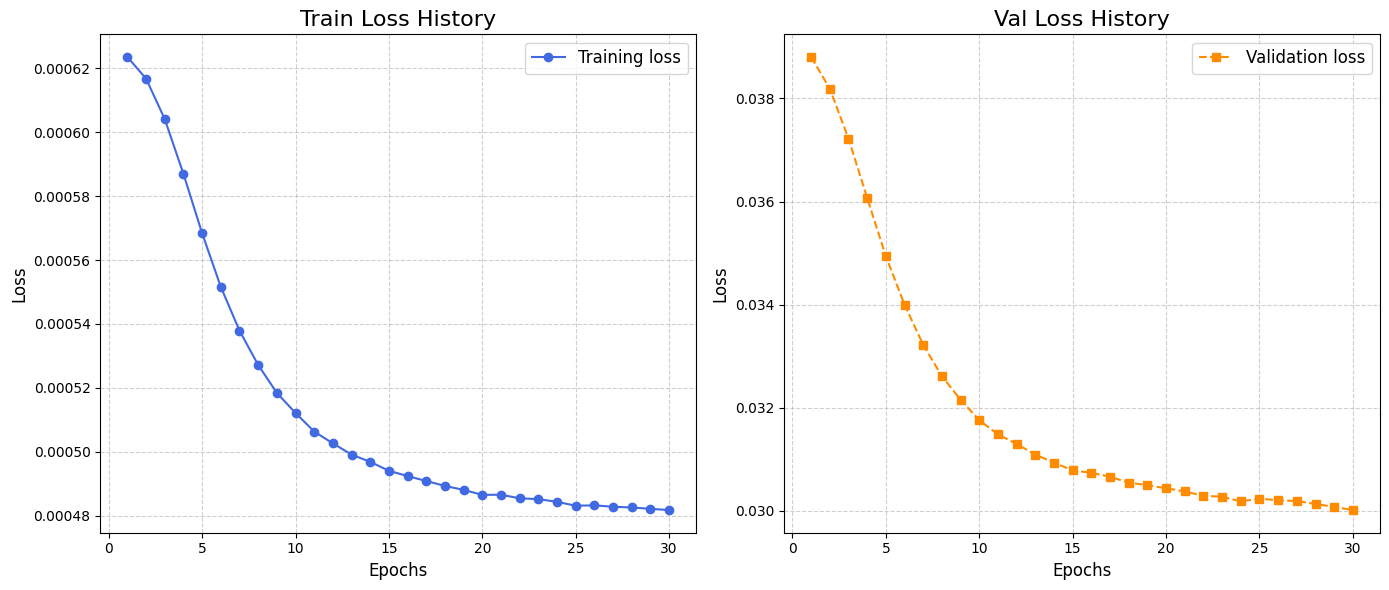

In [18]:
import matplotlib.pyplot as plt
import os

def plot_training_curves(train_loss_hist, val_loss_hist, save_path=None):
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    epochs = range(1, len(train_loss_hist) + 1)
    plt.plot(epochs, train_loss_hist, 'o-', label='Training loss', color='royalblue')
    plt.title('Train Loss History', fontsize=16)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.subplot(1, 2, 2)
    epochs = range(1, len(train_loss_hist) + 1)
    plt.plot(epochs, val_loss_hist, 's--', label='Validation loss', color='darkorange')
    plt.title('Val Loss History', fontsize=16)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    if not os.path.exists(f"{save_path}"):
        os.makedirs(f"{save_path}")
    if save_path:
        saveContent = f"{save_path}/{dataset}_Loss.png"
        plt.savefig(saveContent, dpi=1200, bbox_inches='tight')
        print(f"Saved plot to {saveContent}")
    plt.show()

print("正在绘制训练损失图……")
plot_training_curves(train_loss_hist, test_loss_hist, f"results/{type}/Loss")


## ***Saving***

In [19]:

torch.save(best_model, f"weight/{Date}/{filename}")
print(f"Model saved as {filename}")

Model saved as 20260113_1509_None_discrete5cate.pth


In [20]:
# 释放显存
torch.cuda.empty_cache()

## ***Loading***

In [21]:
#torch.serialization.add_safe_globals(torch.serialization.get_unsafe_globals_in_checkpoint(torch.load(f'weight/{Date}/{filename}',weights_only=False)))
torch.serialization.clear_safe_globals()
#torch.serialization.add_safe_globals()
#print(torch.serialization.get_unsafe_globals_in_checkpoint(f'weight/{Date}/{filename}'))
model = torch.load(f'weight/{Date}/{filename}',weights_only=False)
#model = torch.load(f'weight/20250619/20250619_20250619_0718.pth')

## ***Data Analysis***

In [22]:
# 查看
plt.rcParams["figure.figsize"] = (15, 4.5)
def visualize(image, label):
    image_padded = F.pad(image, pad=(PADDINGx, PADDINGx, PADDINGy, PADDINGy))
    image_E = torch.sqrt(image_padded)
    out = model(image_E.to(device))
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, constrained_layout=True)
    ax1.grid(False)
    ax1.imshow(image.squeeze(), interpolation='none', cmap='viridis')
    ax1.set_title(f'Input image with\n total intensity {image.squeeze().sum():.2f}')
    output_image = torch.abs(out[1].squeeze()).detach().cpu()
    ax2.grid(False)
    ax2.imshow(output_image*det_ideal, interpolation='none', cmap='viridis')
    ax2.set_title(f'Output image with\n total intensity {output_image.squeeze().sum():.2f}')
    dist = out[0].squeeze().detach().cpu()
    ax3.bar(range(len(dist)), dist)
    fig.suptitle("label={}".format(label))
    plt.grid(False)
    plt.show()
    print(image.shape)
    print(images_padded.shape)
    print(image_E.shape)


def mask_visualiztion(Date, filename, save_path=None):
    if not os.path.exists(f'post/{Date}/{filename}'):
        os.makedirs(f'post/{Date}/{filename}')
    for ind, mask in enumerate(model.phase_mask):
        ## MATRIX CONSERVATION
        original_matrix = mask.detach().cpu().numpy()
        original_df = pd.DataFrame(original_matrix)
        original_df.to_csv(f'post/{Date}/{currentDate}_{type}_{dataset}.pth/original_mask.csv', index=False, header=False)
        
        original_matrix[original_matrix > 1] -= 1
        original_matrix[original_matrix < 0] += 1
        original_processed_df = pd.DataFrame(original_matrix) #原来的本身的数据
        original_processed_df.to_csv(f'post/{Date}/{currentDate}_{type}_{dataset}.pth/original_mask_processed.csv', index=False, header=False)
        
        print("保存完成！")
        ## VISUALIZATION
        plt.imshow((original_matrix / np.max(original_matrix)) * 1023, interpolation = 'none', cmap='viridis')
        #plt.imshow(mask.detach().cpu()*180/np.pi, interpolation='none')
        plt.title(f'Mask of layer {ind+1}')
        plt.colorbar()
        plt.grid(False)
        if not os.path.exists(f"{save_path}"):
            os.makedirs(f"{save_path}")
        if save_path:
            saveContent = f"{save_path}/{dataset}_Mask.png"
            plt.savefig(saveContent, dpi=1200, bbox_inches='tight')
        print(f"Saved plot to {saveContent}")
        plt.show()

保存完成！
Saved plot to results/None/PhaseMask/discrete5cate_Mask.png


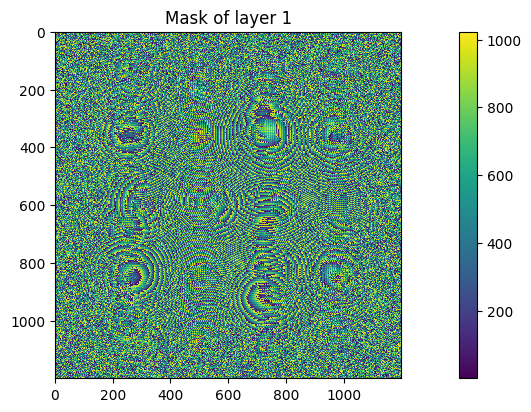

In [23]:
mask_visualiztion(Date, filename, f"results/{type}/PhaseMask")

In [21]:
"""
rand_ind = np.random.choice(range(len(val_dataset)), size=10, replace=False)
for ind in rand_ind:
    visualize(val_dataset[ind][0], val_dataset[ind][1])
 """

'\nrand_ind = np.random.choice(range(len(val_dataset)), size=10, replace=False)\nfor ind in rand_ind:\n    visualize(val_dataset[ind][0], val_dataset[ind][1])\n '

## ***Confusion Matrix***

计算混淆矩阵……
混淆矩阵已保存至: results/None/ConfusionMatrix


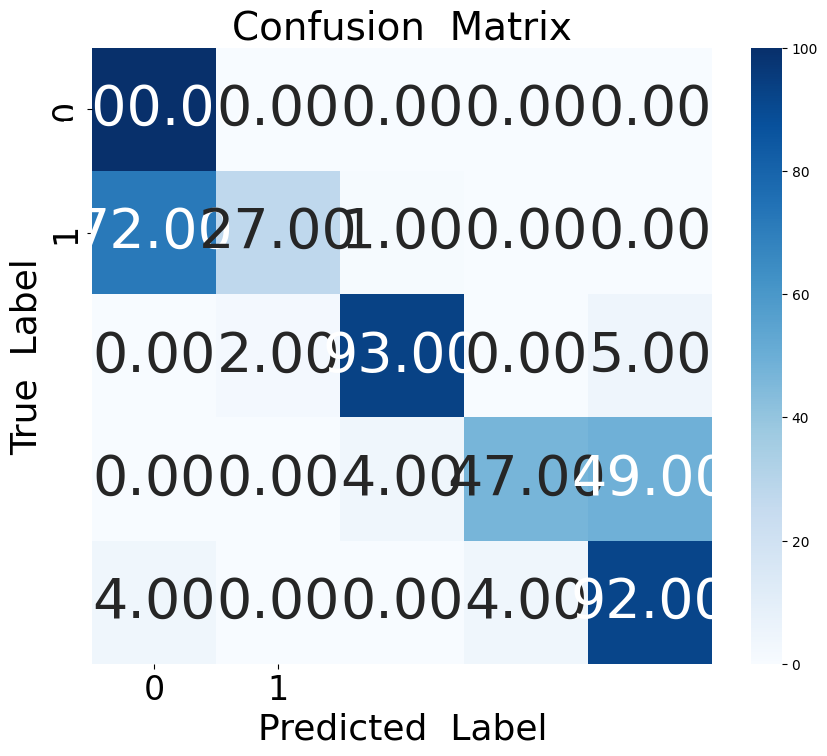

In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix(model, dataloader, device, classes_num, save_path=None):
    model.eval()
    all_labels = []
    all_preds = []
    classesname = [f'{i}' for i in range(classes_num)]
    print("计算混淆矩阵……")
    with torch.no_grad(): # 停止梯度更新
        for i, (images, labels) in enumerate(dataloader):
            images = images.to(device).float()
            images_E = torch.sqrt(F.pad(torch.squeeze(images), pad=(PADDINGx, PADDINGx, PADDINGy, PADDINGy)))
            labels = labels.to(device)

            out_labels, out_images = model(images_E)
            _, predicted = torch.max(out_labels, 1)

            all_labels.append(labels.cpu().numpy())
            all_preds.append(predicted.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm, annot=True, annot_kws={"size": 40}, fmt='.2f', cmap='Blues', xticklabels=classesname, yticklabels=classesname)
    plt.title('Confusion  Matrix', fontsize=28)
    plt.xlabel('Predicted  Label', fontsize=26)
    plt.ylabel('True  Label', fontsize=26)
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    if not os.path.exists(f"{save_path}"):
        os.makedirs(f"{save_path}")
    # 如果提供了保存路径，则保存图像
    if save_path:
        plt.savefig(f"{save_path}/{dataset}_Confusion.png",  dpi=1200, bbox_inches='tight')  # 高分辨率保存，避免裁剪
        print(f"混淆矩阵已保存至: {save_path}")

    plt.show()   # 显示图像


confusion_matrix_result = plot_confusion_matrix(model, val_dataloader, device, 2, f"results/{type}/ConfusionMatrix")

In [28]:
def confusion_matrix(predicted, labels, conf_matrix):
    for p, t in zip(predicted, labels):
        conf_matrix[p, t] += 1
    return conf_matrix
#首先定义一个 分类数*分类数 的空混淆矩阵
conf_matrix = torch.zeros(8, 8)
# 使用torch.no_grad()可以显著降低测试用例的GPU占用
with torch.no_grad(): # 停止梯度更新
    for i, (images, labels) in enumerate(val_dataloader):
        images = images.to(device)
        images = torch.sqrt(F.pad(torch.squeeze(images), pad=(PADDINGx, PADDINGx, PADDINGy, PADDINGy)))
        labels = labels.to(device)

        out_labels, out_images = model(images)
        _, predicted = torch.max(out_labels.data, 1)

        #记录混淆矩阵参数
        conf_matrix = confusion_matrix(predicted, labels, conf_matrix)
        conf_matrix = conf_matrix.cpu()

KeyboardInterrupt: 

In [26]:
conf_matrix = np.array(conf_matrix)# 将混淆矩阵从gpu转到cpu再转到np
corrects = conf_matrix.diagonal(offset = 0)#抽取对角线的每种分类的识别正确个数
per_classes = conf_matrix.sum(axis = 1)#抽取每个分类数据总的测试条数

print("混淆矩阵总元素个数：{},测试集总个数:{}".format(int(np.sum(conf_matrix)), BATCH_SIZE*len(val_dataloader)))
np.set_printoptions(suppress=True)
print(conf_matrix)

# 获取每种label的识别准确率
percent = [rate*100 for rate in corrects/per_classes]
per_classes = list(per_classes)
corrects = list(corrects)

print("每种标签总个数：{}".format('  '.join(['{:.0f}'.format(i) for i in per_classes])))
print("每种标签预测正确的个数：{}".format('  '.join(['{:.0f}'.format(i) for i in corrects])))
print("每种标签的识别准确率为：{}".format('%  '.join(['{:.1f}'.format(i) for i in percent])), end='%')

混淆矩阵总元素个数：500,测试集总个数:512
[[99. 72.  2.  0.  3.  0.  0.  0.]
 [ 1. 27.  7.  0.  0.  0.  0.  0.]
 [ 0.  1. 84.  3.  0.  0.  0.  0.]
 [ 0.  0.  0. 50.  6.  0.  0.  0.]
 [ 0.  0.  7. 47. 91.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]]
每种标签总个数：176  35  88  56  145  0  0  0
每种标签预测正确的个数：99  27  84  50  91  0  0  0
每种标签的识别准确率为：56.2%  77.1%  95.5%  89.3%  62.8%  nan%  nan%  nan%

C:\Users\16329\AppData\Local\Temp\ipykernel_36632\2856683480.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  conf_matrix = np.array(conf_matrix)# 将混淆矩阵从gpu转到cpu再转到np
C:\Users\16329\AppData\Local\Temp\ipykernel_36632\2856683480.py:10: RuntimeWarning: invalid value encountered in divide
  percent = [rate*100 for rate in corrects/per_classes]


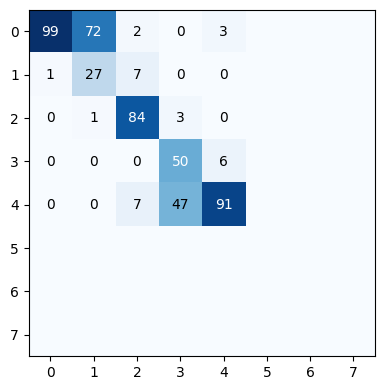

In [27]:
# 绘制混淆矩阵
"""
label_ticks = list()
for i in range(num_classes):
    label_ticks = label_ticks + ['{}'.format(classes[i])]
"""
# 显示数据
plt.imshow(conf_matrix, cmap=plt.cm.Blues)
thresh = conf_matrix.max() / 2	#数值颜色阈值，如果数值超过这个，就颜色加深。
for i in range(num_classes):
    for j in range(num_classes):
        info = int(conf_matrix[j, i])
        plt.text(i, j, info,
                 verticalalignment='center',
                 horizontalalignment='center',
                 color="white" if info > thresh else "black")
plt.show()